## Importing Libraries

In [3]:
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
import evaluate
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import LoraConfig, TaskType, get_peft_model
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM

import matplotlib.pyplot as plt

In [4]:
device = 'cuda'

## 1. Dataset Preparation

In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
dataset_path = "/content/drive/MyDrive/Kaarshika/datasets/kaarshika_sft_5000.jsonl"

In [9]:
dataset = load_dataset("json", data_files = dataset_path)
print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'metadata', 'messages'],
        num_rows: 5000
    })
})


In [10]:
dataset = dataset.shuffle(seed = 42)

In [13]:
dataset['train'][5]

{'id': 'KAARSHIKA_04805',
 'category': 'E_decision_selected_action',
 'task': 'final_decision_response',
 'metadata': {'crop': 'rice',
  'topic': None,
  'location': None,
  'stage': 'seedling',
  'soil_moisture': 'high',
  'rain_probability': 'high',
  'candidate_actions': ['WAIT_FOR_RAIN', 'IMPROVE_DRAINAGE', 'MONITOR'],
  'rl_selected_action': 'MONITOR',
  'temperature': None,
  'humidity': None,
  'water_availability': None},
 'messages': [{'role': 'system',
   'content': "You are KAARSHIKA's conversational response generator. The decision engine has already selected the action. Explain it clearly without changing the selected action."},
  {'role': 'user',
   'content': 'Farmer query: Which action should I take for my rice field?\n\nFarm context:\nCrop: rice\nStage: seedling\nSoil moisture: high\nRain probability: high\nRetrieved guidance: Consider crop stage, soil moisture and rainfall.\n\nRL-selected action: MONITOR'},
  {'role': 'assistant',
   'content': 'I recommend monitoring

### Train-Test Split

In [15]:
dataset_split = dataset['train'].train_test_split(test_size = 0.2, seed = 42)
train_dataset = dataset_split['train']
test_dataset = dataset_split['test']

dataset_split

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'task', 'metadata', 'messages'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['id', 'category', 'task', 'metadata', 'messages'],
        num_rows: 1000
    })
})

In [30]:
def format_chat(example):
    return {
        "text": tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False
        )
    }

train_dataset = train_dataset.map(format_chat)
test_dataset = test_dataset.map(format_chat)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

## Model

In [16]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

In [17]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype = torch.float16,
    device_map = 'auto'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [18]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Perform Fine-Tuning with LoRA

In [25]:
lora_config = LoraConfig (
    task_type = TaskType.CAUSAL_LM,
    r = 16,
    lora_alpha = 32,
    lora_dropout = 0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    bias="none"
)

### Wrapping model with LoRA

In [26]:
model = get_peft_model(model, lora_config)

In [27]:
model.print_trainable_parameters()

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


### SFT Config

In [28]:
from trl import SFTConfig

sft_config = SFTConfig(
    output_dir = "/content/drive/MyDrive/KAARSHIKA/models/qwen2.5-3b-lora",

    num_train_epochs = 2,

    per_device_train_batch_size = 1,
    per_device_eval_batch_size = 1,

    gradient_accumulation_steps = 8,

    learning_rate = 2e-4,

    fp16 = True,

    logging_steps = 10,
    eval_steps = 100,
    save_steps = 100,

    evaluation_strategy = "steps",
    save_strategy = "steps",

    max_seq_length = 512,

    report_to = "none",

    load_best_model_at_end = False,

    seed = 42,
)

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


### SFT Trainer

In [34]:
trainer = SFTTrainer(
    model, 
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    tokenizer = tokenizer,
    dataset_text_field = "text",
    args = sft_config,
    peft_config = lora_config
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [35]:
trainer.train()

Step,Training Loss,Validation Loss
100,0.086800,0.089151
200,0.081600,0.081966
300,0.081000,0.079468
400,0.077500,0.079765
500,0.078200,0.079471
600,0.077900,0.077594
700,0.077400,0.077114
800,0.076300,0.076388
900,0.076000,0.076386
1000,0.075400,0.075829


TrainOutput(global_step=1000, training_loss=0.1075223041176796, metrics={'train_runtime': 4039.1825, 'train_samples_per_second': 1.981, 'train_steps_per_second': 0.248, 'total_flos': 1.6044518989922304e+16, 'train_loss': 0.1075223041176796, 'epoch': 2.0})

In [36]:
log_history_lora = trainer.state.log_history

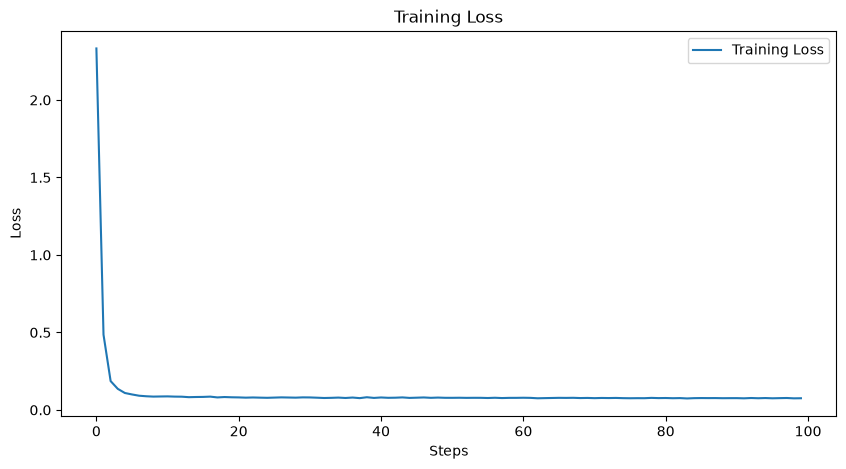

In [37]:
train_loss = [log['loss'] for log in log_history_lora if 'loss' in log]

plt.figure(figsize = (10, 5))
plt.plot(train_loss, label = 'Training Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

In [39]:
trainer.save_model(
    "/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora"
)

('/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora/tokenizer_config.json',
 '/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora/special_tokens_map.json',
 '/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora/vocab.json',
 '/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora/merges.txt',
 '/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora/added_tokens.json',
 '/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora/tokenizer.json')

---

# Inference Section

In [3]:
import torch
import os

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import PeftModel


OFFLOAD_DIR = "/content/offload"
os.makedirs(OFFLOAD_DIR, exist_ok=True)

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"
LORA_PATH = "/content/drive/MyDrive/Kaarshika/models/qwen2.5-3b-lora"

# setting up tokenizer
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

# setting up base model
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype = torch.float16,
    offload_folder = OFFLOAD_DIR
).to('cuda')

# attaching LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    LORA_PATH
)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
gen_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    batch_size=2,
    truncation=True,
    padding=False,
    return_full_text=False
)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FalconMambaForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'GraniteForCausalLM', 'GraniteMoeForCausalLM', 'JambaFor

In [5]:
from transformers import TextIteratorStreamer
from threading import Thread

In [6]:
def generate_response(user_prompt, max_new_tokens=200):

    messages = [
        {
            "role": "system",
            "content": (
                "You are Kaarshika's conversational response generator. "
                "The decision engine has already selected the action. "
                "Explain it clearly without changing the selected action."
            )
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    streamer = TextIteratorStreamer(
        tokenizer,
        skip_prompt=True,
        skip_special_tokens=True
    )

    generation_kwargs = {
        **inputs,
        "streamer": streamer,
        "max_new_tokens": max_new_tokens,
        "do_sample": False,
        "eos_token_id": tokenizer.eos_token_id
    }

    thread = Thread(
        target=model.generate,
        kwargs=generation_kwargs
    )

    thread.start()

    for new_text in streamer:
        print(new_text, end="", flush=True)

    thread.join()

In [25]:
prompt = """Farmer query: Should I irrigate my soybean field?

Farm context:
Crop: soybean
Stage: flowering
Soil moisture: moderate
Rain probability: high
Retrieved guidance: Rainfall is expected soon and may satisfy current water requirements.

RL-selected action: WAIT_FOR_RAIN
"""

generate_response(prompt)

Given the expected rainfall and current soil moisture, I recommend waiting and reassessing after the rain.